In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import os

# Konfigurasi Hyperparameter
TIME_STEPS = 7
EPOCHS = 50
BATCH_SIZE = 8

In [2]:
df = pd.read_csv("data_transaksi.csv")
df['tanggal'] = pd.to_datetime(df['tanggal'])

# Memilih Produk Unggulan secara otomatis
top_product_id = df['product_id'].value_counts().index[0]
print(f"Fokus peramalan pada Produk: {top_product_id}")

# Filter transaksi dan agregasi jumlah penjualan harian
df_prod = df[df['product_id'] == top_product_id].copy()
daily_sales = df_prod.groupby('tanggal')['qty'].sum().reset_index()

# Mengisi tanggal yang kosong dengan 0 agar time-series kontinu
daily_sales = daily_sales.set_index('tanggal').asfreq('D', fill_value=0)

# Menampilkan 5 data terakhir
daily_sales.tail()

Fokus peramalan pada Produk: PKG-BTL-01


,qty
tanggal,
2025-08-14,0
2025-08-15,0
2025-08-16,0
2025-08-17,7500
2025-08-18,2500


In [3]:
# Ekstrak nilai dan ubah skala data ke 0-1
raw_data = daily_sales['qty'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(raw_data)

# Membentuk array input (X) dan label (y)
X, y = [], []
for i in range(len(scaled_data) - TIME_STEPS):
    X.append(scaled_data[i : i + TIME_STEPS])
    y.append(scaled_data[i + TIME_STEPS])
    
X, y = np.array(X), np.array(y)

print(f"Bentuk Input Tensor X : {X.shape}") # (Jumlah_Sampel, TIME_STEPS, 1)
print(f"Bentuk Label Tensor y : {y.shape}") # (Jumlah_Sampel, 1)

Bentuk Input Tensor X : (41, 7, 1)
Bentuk Label Tensor y : (41, 1)


In [4]:
# Mendefinisikan arsitektur
model = Sequential([
    LSTM(32, activation='relu', input_shape=(TIME_STEPS, 1)),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\andre\.conda\envs\ta-skripsi\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Melatih model
print("\nMemulai training model...")
history = model.fit(
    X, y, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    verbose=1
)


Memulai training model...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0744
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0704 
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0682 
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0663 
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0658 
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0647 
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0642 
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0641 
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0639 
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0640 
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0636 
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0637 
Epoch 13/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0636 
Epoch 14/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0637 
Epoch 15/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0632 
Epoch 16

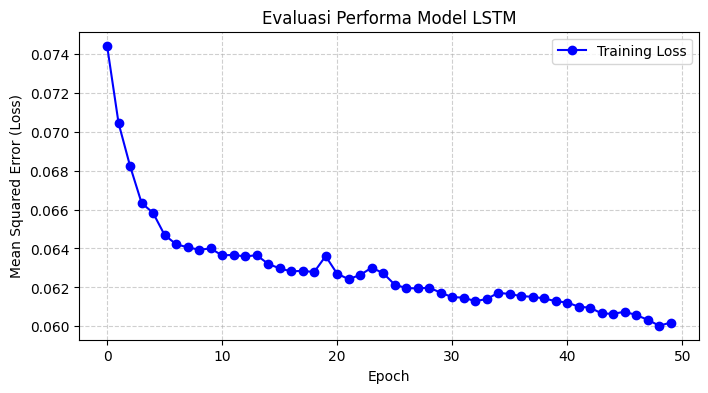

In [6]:
# Menampilkan grafik penurunan Loss (MSE)
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.title('Evaluasi Performa Model LSTM')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
# Membuat folder dan menyimpan artefak
os.makedirs('model_lstm', exist_ok=True)
model_path = f"model_lstm/lstm_{top_product_id}.keras"
scaler_path = f"model_lstm/scaler_{top_product_id}.pkl"

model.save(model_path)
joblib.dump(scaler, scaler_path)
print(f"Berhasil menyimpan model di: {model_path}")

Berhasil menyimpan model di: model_lstm/lstm_PKG-BTL-01.keras


In [8]:
# Melakukan inferensi untuk 1 hari ke depan
last_sequence = scaled_data[-TIME_STEPS:]
last_sequence_reshaped = last_sequence.reshape(1, TIME_STEPS, 1)

prediksi_scaled = model.predict(last_sequence_reshaped, verbose=0)
prediksi_asli = scaler.inverse_transform(prediksi_scaled)

print("-" * 50)
print(f"Prediksi permintaan besok (Hari ke-1) untuk {top_product_id} : {int(np.round(prediksi_asli[0][0]))} unit")
print("-" * 50)

--------------------------------------------------
Prediksi permintaan besok (Hari ke-1) untuk PKG-BTL-01 : 2139 unit
--------------------------------------------------


### Modeling untuk semua product - predict 1 hari

In [12]:

daftar_produk = df['product_id'].unique()
print(f"Ditemukan {len(daftar_produk)} produk unik. Memulai proses training batch...\n")

for product_id in daftar_produk:
    print("-" * 50)
    print(f"Mempersiapkan model untuk: {product_id}")
    
    # Filter transaksi spesifik produk ini
    df_prod = df[df['product_id'] == product_id].copy()
    daily_sales = df_prod.groupby('tanggal')['qty'].sum().reset_index()
    
    # Memastikan deret waktu kontinu (isi hari kosong dengan 0)
    daily_sales = daily_sales.set_index('tanggal').asfreq('D', fill_value=0)
    
    # Validasi Keamanan: Pastikan data historis cukup panjang
    if len(daily_sales) <= TIME_STEPS:
        print(f"⚠️ Melewati {product_id}: Data historis terlalu sedikit ({len(daily_sales)} hari).")
        continue
        
    raw_data = daily_sales['qty'].values.reshape(-1, 1)
    
    # Normalisasi (Masing-masing produk punya skalanya sendiri)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(raw_data)
    
    # Membuat Sliding Window
    X, y = [], []
    for i in range(len(scaled_data) - TIME_STEPS):
        X.append(scaled_data[i : i + TIME_STEPS])
        y.append(scaled_data[i + TIME_STEPS])
        
    X, y = np.array(X), np.array(y)
    
    # Membangun Arsitektur Model
    model = Sequential([
        Input(shape=(TIME_STEPS, 1)),
        LSTM(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    
    print(f"Sedang melatih model...")
    # Training dengan verbose=0 agar layar tidak dipenuhi ribuan baris log per produk
    model.fit(
        X, 
        y, 
        epochs=40, 
        batch_size=8, 
        verbose=0
    )
    
    # Menyimpan Artefak Model & Scaler
    model_path = f"model_lstm/lstm_{product_id}.keras"
    scaler_path = f"model_lstm/scaler_{product_id}.pkl"
    
    model.save(model_path)
    joblib.dump(scaler, scaler_path)
    print(f"✅ Selesai! Disimpan ke: {model_path}")

print("\n" + "=" * 50)
print("🎉 SELURUH PROSES TRAINING BATCH SELESAI!")

Ditemukan 8 produk unik. Memulai proses training batch...

--------------------------------------------------
Mempersiapkan model untuk: PKG-BOX-02
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-BOX-02.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-PCH-01
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-PCH-01.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-TRY-01
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-TRY-01.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-BTL-02
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-BTL-02.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-BTL-01
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-BTL-01.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-CAP-01
Se

### Modeling untuk predict mingguan

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import joblib
import os

# Konfigurasi Arsitektur Multi-step
N_PAST = 14    # Jumlah hari ke belakang sebagai input
N_FUTURE = 7   # Jumlah hari ke depan yang diprediksi sekaligus

df = pd.read_csv("data_transaksi.csv")
df['tanggal'] = pd.to_datetime(df['tanggal'])
daftar_produk = df['product_id'].unique()
print(f"Ditemukan {len(daftar_produk)} produk unik. Memulai proses training batch...\n")

# Buat folder jika belum ada
os.makedirs("model_lstm", exist_ok=True)

for product_id in daftar_produk:
    print("-" * 50)
    print(f"Mempersiapkan model untuk: {product_id}")
    
    df_prod = df[df['product_id'] == product_id].copy()
    daily_sales = df_prod.groupby('tanggal')['qty'].sum().reset_index()
    daily_sales = daily_sales.set_index('tanggal').asfreq('D', fill_value=0)
    
    # Validasi Keamanan: Pastikan data historis cukup untuk (Input + Output)
    if len(daily_sales) <= (N_PAST + N_FUTURE):
        print(f"⚠️ Melewati {product_id}: Data historis terlalu sedikit ({len(daily_sales)} hari).")
        continue
        
    raw_data = daily_sales['qty'].values.reshape(-1, 1)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(raw_data)
    
    # REVISI: Membuat Sliding Window untuk Multi-step Output
    X, y = [], []
    for i in range(len(scaled_data) - N_PAST - N_FUTURE + 1):
        X.append(scaled_data[i : i + N_PAST])
        # Mengambil array sebanyak N_FUTURE untuk target y
        y.append(scaled_data[i + N_PAST : i + N_PAST + N_FUTURE, 0])
        
    X, y = np.array(X), np.array(y)
    
    # REVISI: Membangun Arsitektur Model Direct Multi-step
    model = Sequential([
        Input(shape=(N_PAST, 1)),
        LSTM(64, activation='relu'), # Kapasitas memori dinaikkan sedikit untuk input yang lebih panjang
        Dense(32, activation='relu'),
        Dense(N_FUTURE, activation='linear') # Output layer menghasilkan 7 titik sekaligus
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    print(f"Sedang melatih model...")
    model.fit(
        X, 
        y, 
        epochs=50, # Epochs sedikit dinaikkan karena pola lebih kompleks
        batch_size=8, 
        verbose=0
    )
    
    model_path = f"model_lstm/lstm_{product_id}.keras"
    scaler_path = f"model_lstm/scaler_{product_id}.pkl"
    
    model.save(model_path)
    joblib.dump(scaler, scaler_path)
    print(f"✅ Selesai! Disimpan ke: {model_path}")

print("\n" + "=" * 50)
print("🎉 SELURUH PROSES TRAINING BATCH SELESAI!")

Ditemukan 8 produk unik. Memulai proses training batch...

--------------------------------------------------
Mempersiapkan model untuk: PKG-BOX-02
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-BOX-02.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-PCH-01
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-PCH-01.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-TRY-01
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-TRY-01.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-BTL-02
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-BTL-02.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-BTL-01
Sedang melatih model...
✅ Selesai! Disimpan ke: model_lstm/lstm_PKG-BTL-01.keras
--------------------------------------------------
Mempersiapkan model untuk: PKG-CAP-01
Se